In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import seaborn as sns

In [2]:
# wti = pd.read_csv("wti_prices.csv", parse_dates=['Date'])
# wti = wti.sort_values('Date')

# wti_price_col = 'WTI_price' 
# wti['log_return'] = np.log(wti[wti_price_col]).diff()
# wti['ylag_jitter'] = wti['log_return'].shift(1) # keep lagged log return for jittering

# wti.head()

In [3]:
# predictors = pd.read_csv("predictor_data.csv", parse_dates=['Date'])
# predictors = predictors.sort_values('Date')
# predictors.head()

In [4]:
# cols = ['CPI', 'TB3MS', 'M1', 'M2', 'AUD_USD', 'CAD_USD', 'NZD_USD', 'ZAR_USD']

# # --- Plot ---
# fig, axes = plt.subplots(4, 2, figsize=(14, 12))
# for ax, col in zip(axes.flatten(), cols):
#     ax.plot(predictors['Date'], predictors[col], linewidth=0.8)
#     ax.set_title(col)
#     ax.set_xlabel('')
# plt.suptitle('Predictor Series — Raw Levels', fontsize=14, y=1.01)
# plt.tight_layout()
# plt.show()

In [5]:
# # --- ADF Tests ---
# print(f"{'Series':<12} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
# print("-" * 48)
# for col in cols:
#     result = adfuller(predictors[col].dropna(), autolag='AIC')
#     adf_stat, p_val = result[0], result[1]
#     stationary = 'Yes' if p_val < 0.05 else 'No'
#     print(f"{col:<12} {adf_stat:>10.3f} {p_val:>10.4f} {stationary:>12}")

In [6]:
# to_diff = cols # all nonstationary

# predictors_transformed = predictors.copy()

# for col in to_diff:
#     predictors_transformed[col] = predictors_transformed[col].diff()

# # Drop the NaN row introduced by differencing
# predictors_transformed = predictors_transformed.dropna().reset_index(drop=True)

# # --- Confirm stationarity post-differencing ---
# print(f"{'Series':<12} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
# print("-" * 48)
# for col in to_diff:
#     result = adfuller(predictors_transformed[col].dropna(), autolag='AIC')
#     adf_stat, p_val = result[0], result[1]
#     stationary = 'Yes' if p_val < 0.05 else 'No'
#     print(f"{col:<12} {adf_stat:>10.3f} {p_val:>10.4f} {stationary:>12}")

# predictors_transformed.head()

In [7]:
# # append wti to selected predictors (treasury rate)
# df_raw = wti[['Date', 'log_return']].merge(predictors_transformed[['Date', 'TB3MS']], on='Date', how='inner')
# df_raw.dropna(inplace=True)
# df_raw.head()

In [8]:
df_raw = pd.read_csv("final_data.csv", parse_dates=['Date'])
df_raw['wti_ret_jitt']=df_raw['wti_ret'] # create new col for jittering
df_raw = df_raw.sort_values('Date')

df_raw.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret,wti_ret_jitt
0,1986-02-01,-0.001030,-0.001919,0.029004,-0.122803,-0.005468,-0.01,0.003518,0.000302,-0.394190,-0.394190
1,1986-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.003663,-0.50,0.007092,0.003699,-0.203766,-0.203766
2,1986-04-01,0.020833,-0.009353,0.060724,0.005213,0.001811,-0.50,-0.001419,0.001697,0.018075,0.018075
3,1986-05-01,0.006006,-0.008792,0.009556,0.067115,0.006429,0.09,0.005246,0.000797,0.180503,0.180503
4,1986-06-01,-0.054147,0.010266,-0.037406,0.144931,0.000907,0.06,-0.003911,-0.002716,-0.135577,-0.135577


# Gaussian Noise Injection
- adding noise to training data

$$
\epsilon_t \sim \mathcal{N}(0, \alpha^2 \sigma_Y^2)
$$

-  $\alpha=0.03$ from (Abbasi et al.,2024) -> take 3% of signal's standard deviation
- jittering data prep:
    - split train/val/test
    - add noise $\epsilon \sim \mathscr{N}(0,\alpha^2) $ to train
    - concat data -> final train_augmented.csv

In [9]:
n = len(df_raw)
train_end = int(n * 0.70) # 70/15/15 split
# val_end   = int(n * 0.85)

train_df = df_raw.iloc[:train_end].copy()
val_test_df   = df_raw.iloc[train_end:].copy()
val_test_df['wti_ret_jitt'] = -1 # set to dummy value to exclude from jittering

print(f"Train: {len(train_df)} rows; {train_df.shape} ({train_df['Date'].iloc[0].date()} to {train_df['Date'].iloc[-1].date()})")
print(f"Val/Test:   {len(val_test_df)} rows; {val_test_df.shape} ({val_test_df['Date'].iloc[0].date()} to {val_test_df['Date'].iloc[-1].date()})")

Train: 336 rows; (336, 11) (1986-02-01 to 2014-01-01)
Val/Test:   144 rows; (144, 11) (2014-02-01 to 2026-01-01)


In [10]:
# --- jittering function
def jitter_df(
    train_data: pd.DataFrame,
    exclude_cols: list = ['Date','wti_ret'],
    alpha: float = 0.03,
    num_copies: int = 1,
    random_state: int = 4101,
) -> pd.DataFrame:
    """
    Jitter training data by adding Gaussian noise scaled to each column's own std.
    Noise for column c: ε ~ N(0, (alpha * std(c))²)

    Params:
        train_data   : original training DataFrame in original levels
        exclude_cols : columns to exclude from jittering (target, date, etc.)
        alpha        : noise as fraction of each series' own std
        num_copies   : number of jittered copies to generate
        random_state : reproducibility seed

    Returns:
        DataFrame with original data (smaple_id=0) + all jittered copies and a 'sample_id' column
    """
    jitter_cols = [c for c in train_data.columns if c not in exclude_cols]
    print(f"Jittering columns: {jitter_cols}")
    noise_scales = alpha * train_data[jitter_cols].std()
    rng = np.random.default_rng(random_state)

    # include original data
    original = train_data.copy()
    original['sample_id'] = 0
    copies = [original]

    for i in range(1, num_copies + 1):
        copy = train_data.copy()

        for col in jitter_cols:
            noise = rng.normal(
                loc=0,
                scale=noise_scales[col],
                size=len(copy)
            )
            copy[col] = copy[col] + noise

        copy['sample_id'] = i
        copies.append(copy)

    return pd.concat(copies, ignore_index=True)

In [11]:
# --- apply jittering
ALPHA = 0.03 
K_COPIES  = 10     # number of augmented copies
SEED      = 4101

train_augmented = jitter_df(train_df, 
                            exclude_cols=['wti_ret', 'Date'],
                            alpha=ALPHA, num_copies=K_COPIES, random_state=SEED)

print(f"Original train size:  {len(train_df)}")
print(f"Augmented train size: {len(train_augmented)}  ({K_COPIES+1}xoriginal)")

Jittering columns: ['AUD_USD_ret', 'CAD_USD_ret', 'NZD_USD_ret', 'ZAR_USD_ret', 'CPI', 'TB3MS', 'M1', 'M2', 'wti_ret_jitt']
Original train size:  336
Augmented train size: 3696  (11xoriginal)


In [12]:
# see jittered samples (sample_id > 0)
train_augmented[train_augmented['sample_id'] > 0].head(10)

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret,wti_ret_jitt,sample_id
336,1986-02-01,-0.000875,-0.002420,0.029558,-0.121434,-0.005316,-0.010312,0.003485,0.000375,-0.394190,-0.394766,1
337,1986-03-01,0.013792,-0.002613,-0.005311,-0.022012,-0.003534,-0.502824,0.007011,0.003490,-0.203766,-0.205804,1
338,1986-04-01,0.020556,-0.009215,0.061734,0.005286,0.001819,-0.512224,-0.001274,0.001668,0.018075,0.017376,1
339,1986-05-01,0.006252,-0.008971,0.010316,0.066980,0.006457,0.095036,0.004920,0.000920,0.180503,0.183175,1
340,1986-06-01,-0.054055,0.011155,-0.036922,0.146202,0.000879,0.056519,-0.004210,-0.002542,-0.135577,-0.135960,1
341,1986-07-01,-0.090908,-0.006466,-0.026476,0.009531,-0.002697,-0.384837,0.001060,0.000333,-0.147348,-0.147564,1
342,1986-08-01,-0.026160,0.005123,-0.060395,0.014270,-0.000025,-0.308422,-0.001672,-0.000905,0.264552,0.266389,1
343,1986-09-01,0.014459,-0.001317,-0.043028,-0.120851,0.002574,-0.318898,0.000643,0.000551,-0.015349,-0.013841,1
344,1986-10-01,0.025892,0.001350,0.049386,-0.026793,-0.002015,-0.028089,-0.001845,-0.000726,0.002015,-0.000286,1
345,1986-11-01,0.009901,-0.002240,0.020389,0.001273,0.000030,0.168764,0.003969,-0.002153,0.021249,0.024137,1


In [13]:
# concatenate: augmented train (11x) + clean val + clean test
val_test_df["sample_id"]  = 0
df_save = pd.concat(
    [train_augmented, val_test_df],
    ignore_index=True
)

# sanity checks
assert df_save[df_save["sample_id"] == 0].shape[0]  == len(df_raw),  "Original train count mismatch"
assert df_save[df_save["wti_ret_jitt"] == -1].shape[0] == len(val_test_df), "Val/test count mismatch"
assert df_save["wti_ret"].equals(                   # target must be untouched throughout
    pd.concat([train_augmented["wti_ret"],
               val_test_df["wti_ret"]], ignore_index=True)
), "Target column was modified — check exclude_cols"

In [14]:
# # --- save augmented data
# df_save.to_csv("final_data_jittered.csv", index=False)

### Plotting one sample

In [15]:
# inspect jittered data
full_augmented = pd.read_csv("final_data_jittered.csv", parse_dates=['Date'])
plot_augmented = train_augmented[train_augmented['sample_id']==1].copy() # inspect first jittered sample
plot_augmented = plot_augmented.drop(columns=['sample_id'])

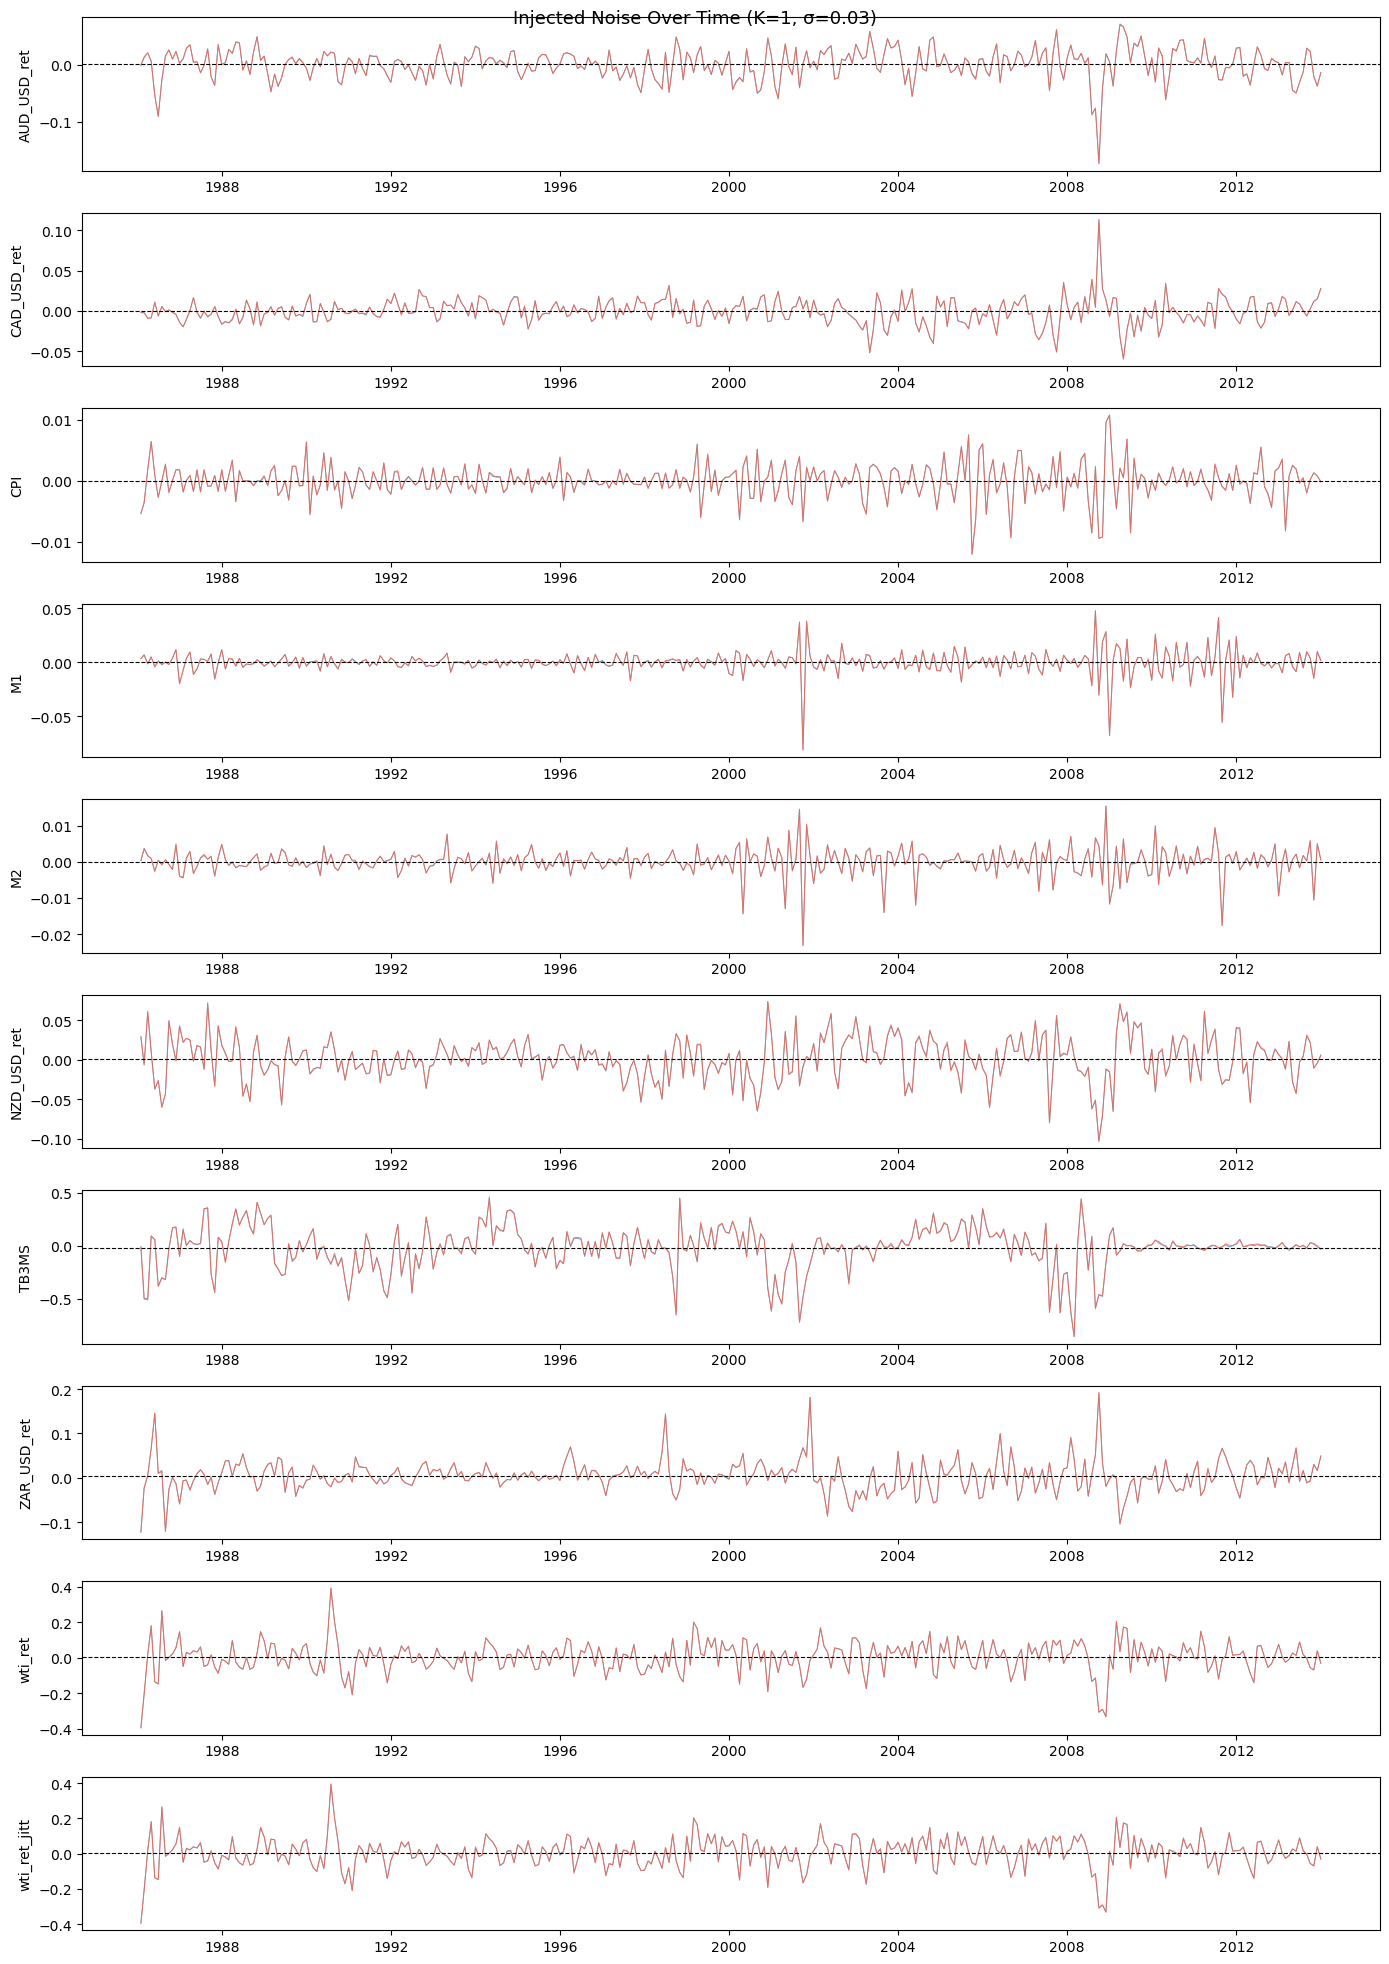

In [ ]:
# plot jittered data
plot_cols = train_df.columns.difference(['Date', 'log_return']).tolist() # only covariates
num_plots = len(plot_cols)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 2*num_plots), sharex=False)

for ax, col in zip(axes, plot_cols):
    orig     = train_df[col].values
    jittered = plot_augmented.iloc[:len(train_df)][col].values
    # noise    = jittered - orig

    # ax.plot(train_df['Date'], noise,
    #         color='tomato', linewidth=0.7, alpha=0.8)
    ax.plot(train_df['Date'], orig,
        color='steelblue', linewidth=0.7, alpha=0.8)
    ax.plot(train_df['Date'], jittered,
        color='tomato', linewidth=0.7, alpha=0.8)
    ax.axhline(np.mean(orig), color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel(col)
    # ax.set_title(col)
    # ax.set_ylim(-0.15, 0.15)  # compress y axis to noise range

plt.suptitle('Injected Noise Over Time (K=1, σ=0.03)', fontsize=13)
plt.tight_layout()
plt.show()

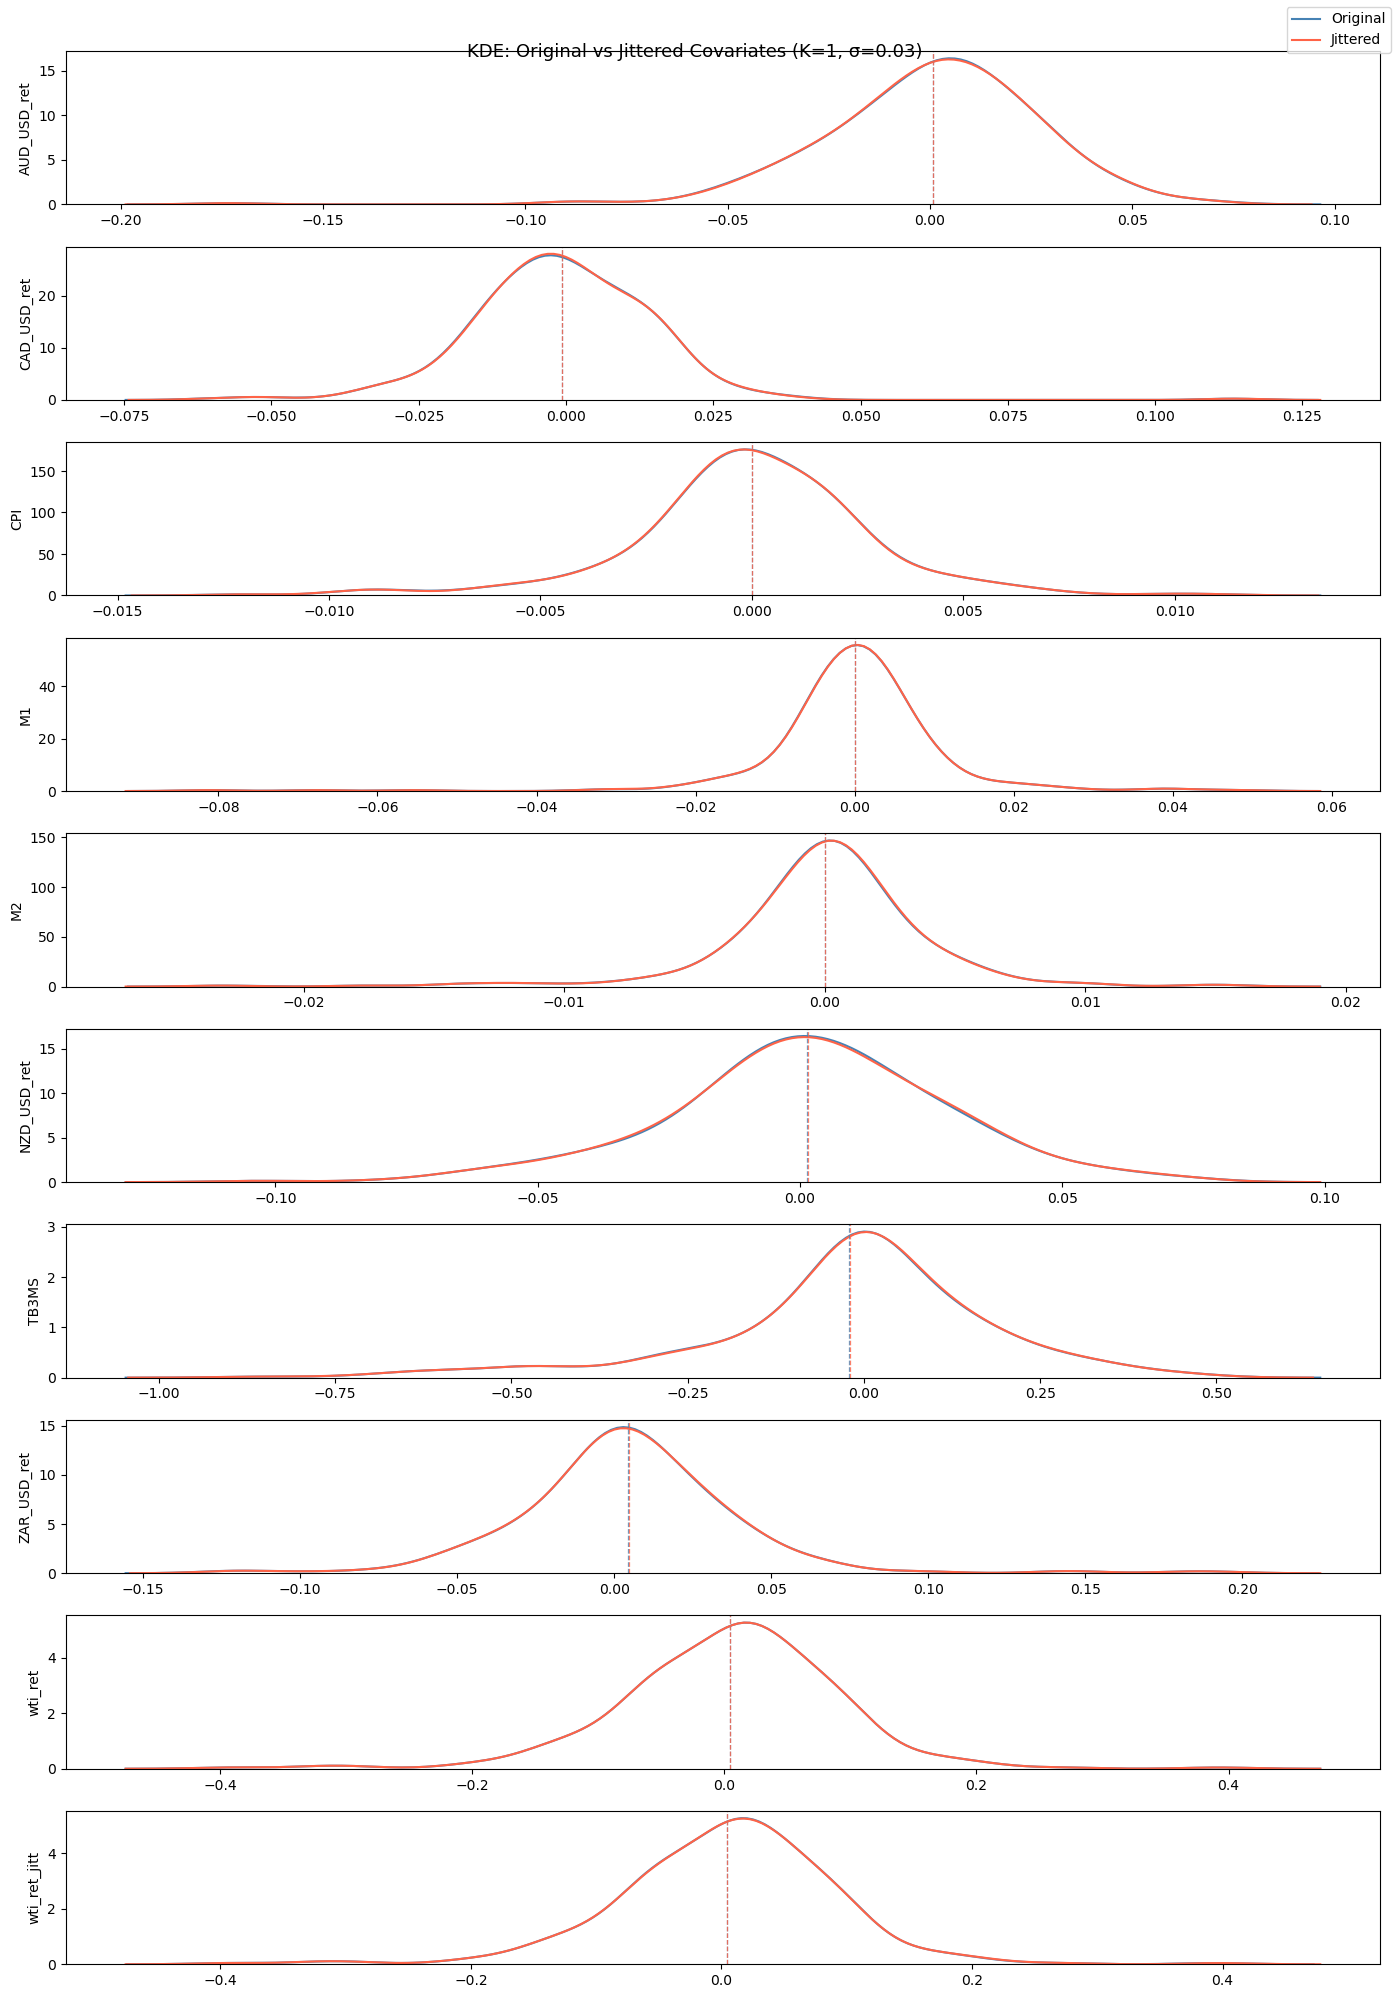

In [17]:
plot_cols = train_df.columns.difference(['Date', 'log_return']).tolist()

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 2*len(plot_cols)), sharex=False)

if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    orig = train_df[col].dropna().values
    jittered = plot_augmented.iloc[:len(train_df)][col].dropna().values

    sns.kdeplot(orig, ax=ax, label='Original', color='steelblue', linewidth=1.5)
    sns.kdeplot(jittered, ax=ax, label='Jittered', color='tomato', linewidth=1.5)

    ax.axvline(np.mean(orig), color='steelblue', linestyle='--', linewidth=0.9, alpha=0.8)
    ax.axvline(np.mean(jittered), color='tomato', linestyle='--', linewidth=0.9, alpha=0.8)

    # ax.set_title(col)
    ax.set_ylabel(col)
    # ax.legend()
lines = [
    plt.Line2D([0], [0], color='steelblue', lw=1.5),
    plt.Line2D([0], [0], color='tomato', lw=1.5),
]
labels = ['Original', 'Jittered']
fig.legend(lines, labels, loc='upper right')

plt.suptitle('KDE: Original vs Jittered Covariates (K=1, σ=0.03)', fontsize=13)
plt.tight_layout()
plt.show()